# Flow of a Darcy fluid injected into a porous rectangle

<!-- $$
\mathbb{S}_{\mathbf{u},p}
\begin{cases}
\Omega = [-L_x/2, L_x/2] \times [-L_y/2, L_y/2] \\
\mathsf{K}=\begin{cases}
K^-(x,y)\mathsf{I} & (x/a)^2 + (y/b)^2 < 1 \\
K^+(x,y)\mathsf{I} & \text{otherwise} 
\end{cases} & \text{lens of low permeability}  \\
\mu = 1 & \text{constant viscosity} \\
u_{\text{E}}(x,y=\pm L_y/2) = 0 & \text{no-penetration on upper and lower boundaries} \\
p_{\text{N}}(x=-L_x/2,y) = p_{\text{in}} & \text{high-pressure left boundary} \\
p_{\text{N}}(x=L_x/2,y) = 0 & \text{low-pressure left boundary} \\
\end{cases}
$$ -->

In [ ]:
# %load_ext autoreload
# %autoreload 2

import numpy as np
from lucifex.mesh import rectangle_mesh, mesh_boundary
from lucifex.fem import Function, Constant
from lucifex.solver import bvp, BoundaryConditions, OptionsPETSc
from lucifex.utils.fenicsx_utils import extract_component_functions
from lucifex.viz import plot_colormap, plot_streamlines, plot_quiver, save_figure
from lucifex.pde.darcy import darcy

Lx = 5.0
Ly = 1.0
Nx = 30
Ny = 30
mesh = rectangle_mesh(Lx, Ly, Nx, Ny, cell='right')
boundary = mesh_boundary(
    mesh, 
    {
        "left": lambda x: x[0],
        "right": lambda x: x[0] - Lx,
        "lower": lambda x: x[1],
        "upper": lambda x: x[1] - Ly,
    },
)

mu = Constant(mesh, 1.0, 'mu')

u_deg = 1
u_elem = ('BDM', u_deg)
p_elem = ('DP', u_deg - 1)
u_p_elem = [u_elem, p_elem]


xIn = 0.25 * Lx
xOut = 0.75 * Lx
uIn_max = 1.0
uStd = 0.1 * Lx
uIn = lambda x: (
    uIn_max * np.exp(((xIn - x[0]) / uStd)**2) 
    - uIn_max * np.exp(((xOut - x[0]) / uStd)**2)
)
# uInFunc = Function(
#     (mesh, 'P', 1, 2), 
#     lambda x: (0.0 * x[0], uIn(x))
# )
u_bcs = BoundaryConditions(
    ('essential', boundary['left', 'right', 'upper'], (0.0, 0.0), 0),
    ('essential', boundary['lower'], (0.0, uIn), 0),
    ('essential', lambda x: np.isclose(x[0], 0.0) & np.isclose(x[1], 0.0), 0.0, 1),
    dofs_locator=('topological', 'topological', 'geometrical'),
)

petsc = OptionsPETSc(
    ksp_type='gmres', 
    pc_type='lu', 
    pc_factor_mat_solver_type='mumps',
)

dk = 0.9
k_sdev = 0.05 * Ly
k = Function(
    (mesh, 'P', 1), 
    lambda x: 1.0 - 0.5 * np.exp(-((Ly/2 - x[1]) / k_sdev)**2),
    name='k',
)

up_mixed = Function((mesh, u_p_elem), name="upMixed")
up_mixed_solver = bvp(darcy, bcs=u_bcs, petsc=petsc)(
    up_mixed, k, mu, blocked=False, add_zero=(True, True),
)

# up_blocked = Function((mesh, u_p_elem), name="upBlocked")
# up_blocked_solver = bvp(darcy, bcs=u_bcs, petsc=petsc)(
#     up_blocked, k, mu, bcs=p_bcs, blocked=True, add_zero=(True, True),
# )

In [10]:
up_mixed_solver.solve()
# up_blocked_solver.solve()

uMixed, pMixed = up_mixed.split(collapse=True)
uxMixed, uyMixed = extract_component_functions(('P', 1), uMixed)
# uBlocked, pBlocked = up_blocked.split(collapse=True)

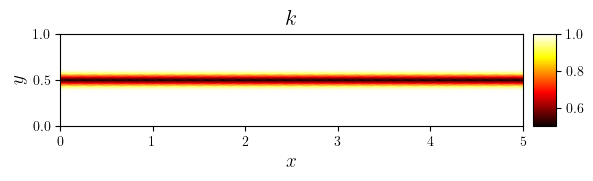

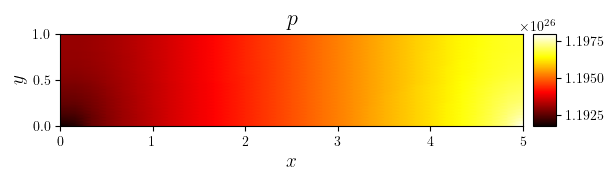

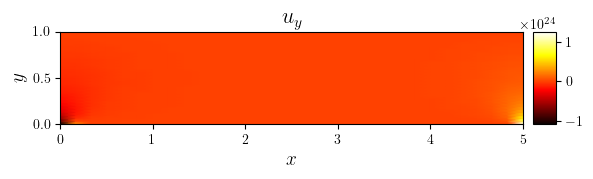

: 

In [ ]:
fig, ax = plot_colormap(k, title='$k$', x_label='$x$', y_label='$y$')
fig, ax = plot_colormap(pMixed, title='$p$', x_label='$x$', y_label='$y$')
fig, ax = plot_colormap(uyMixed, title='$u_y$', x_label='$x$', y_label='$y$')

# fig, ax = plot_colormap(pBlocked, title='$p$', x_label='$x$', y_label='$y$')

In [ ]:
fig, ax = plot_colormap(k, title='$k$', x_label='$x$', y_label='$y$')

In [ ]:
u, p = up.split(('u', 'p'), collapse=True)
ux, uy = extract_component_functions(('P', 1), u, names=('ux', 'uy'))
fig, ax = plot_colormap(k, title='$k$', x_label='$x$', y_label='$y$')
fig, ax = plot_colormap(p, title='$p$', x_label='$x$', y_label='$y$')
fig, ax = plot_colormap(ux, title='$u_x$', x_label='$x$', y_label='$y$')
fig, ax = plot_colormap(uy, title='$u_y$', x_label='$x$', y_label='$y$')
plot_streamlines(fig, ax, (ux, uy), density=0.75, color='cyan')
# save_figure(f'{k.name}_p(x,y)', thumbnail=(k is k_dcts))(fig)
# fig, ax = plot_quiver((ux, uy), arrow_slc=7, title="$\mathbf{u}=(u_x, u_y)$")
# save_figure(f'{k.name}_u(x,y)')(fig)
# fig, ax = plot_colormap(k, title='$K$')